In [6]:
import pandas as pd
import numpy as np
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

In [3]:
df = pd.read_csv('../synthetic_data/synthetic_example.csv')

In [4]:
df

,Company,Project Name,Input Date,Status,Requester,Request Type,Priority,Request,Device,Browser,Page,Estimated Time (tokens),Real Time,ClientStrategicFit
0,Lee PLC,Little Redesign – Chocolate,26/10/2020,Complete,Peter Pugh,Design Issues,Urgent,Reporting a detail in Little Redesign – Chocol...,Desktop,Safari,https://www.littleredesign–chocolate.com,3,2,2.09
1,"Murphy, Wright and Jensen",Sign Landing – DarkOliveGreen,15/11/2024,Complete,Monica Edwards,New Item,Normal,"Monica Edwards, Murphy, Wright and Jensen – sm...",Mobile,Safari,https://www.signlanding–darkolivegreen.com,8,5,3.33
2,Wilson and Sons,Decide Website – MediumOrchid,20/11/2021,Complete,Christopher Durham,New Item,Urgent,"Christopher Durham, Wilson and Sons – small is...",Mobile,Firefox,https://www.decidewebsite–mediumorchid.com,8,6,3.77
3,"Sosa, Bell and King",Military Campaign – MediumSeaGreen,01/02/2020,Complete,Kenneth Hancock,Design Issues,High,"Hi all, reviewing Military Campaign – MediumSe...",Desktop,Chrome,https://www.militarycampaign–mediumseagreen.com,1,1,3.01
4,Monroe-Hinton,Everybody Landing – OrangeRed,18/03/2022,Complete,Tammy Steele,New Item,Urgent,Reporting a detail in Everybody Landing – Oran...,Mobile,Safari,https://www.everybodylanding–orangered.com,5,4,1.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Wilson and Sons,Rate Redesign – DarkSlateBlue,15/12/2021,Complete,Catherine Long,Copy Revision,Low,Noticed something odd in the contact form. Con...,Desktop,Edge,https://www.rateredesign–darkslateblue.com,1,1,3.77
9996,Miles LLC,Outside Platform – Red,23/10/2021,Complete,Bryan Frazier,Copy Revision,Low,Hi there! Bryan Frazier from Miles LLC here. T...,Desktop,Safari,https://www.outsideplatform–red.com,2,2,3.39
9997,Davis-Hernandez,Who Redesign – NavajoWhite,22/03/2024,Complete,Thomas Hoover,Requested Change,Normal,Reporting a detail in Who Redesign – NavajoWhi...,Desktop,Firefox,https://www.whoredesign–navajowhite.com,13,10,3.01
9998,Brown-Flores,Place Revamp – PaleGoldenRod,22/04/2024,Complete,Mark Woodard,New Item,Urgent,Hi! I’m looking at Place Revamp – PaleGoldenRo...,Desktop,Safari,https://www.placerevamp–palegoldenrod.com,8,6,3.77


### EDA Y ANÁLISIS DEL DATASET

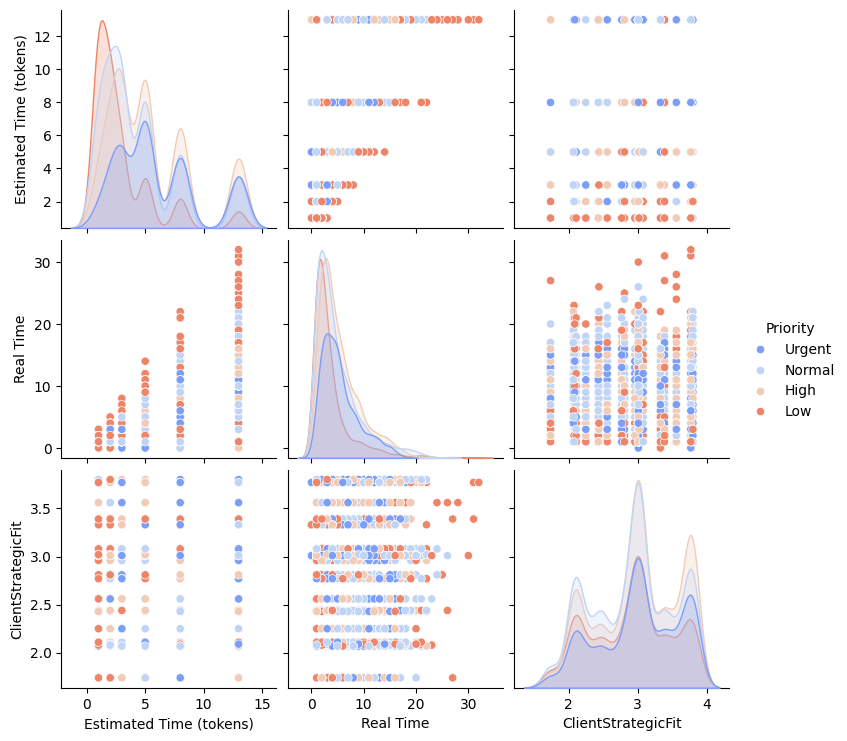

In [ ]:
# GRAFICO CONEL ESTIMATEd time y la priority 
sns.pairplot(data=, hue='Priority', palette='coolwarm')

<Axes: xlabel='Request Type', ylabel='count'>

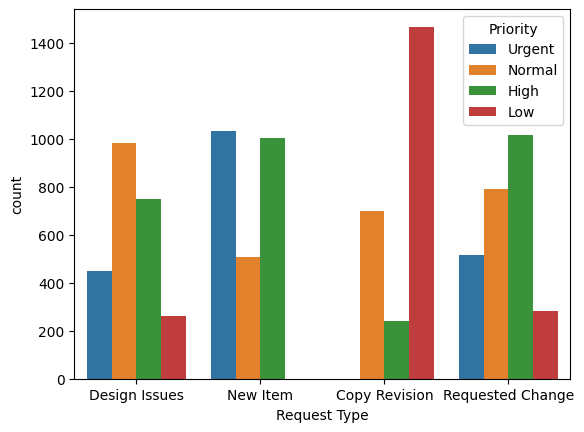

In [20]:
# GRAFICO DE REQUEST TIME Y PRIORITY
sns.countplot(data=df, x='Request Type', hue='Priority')

<Axes: >

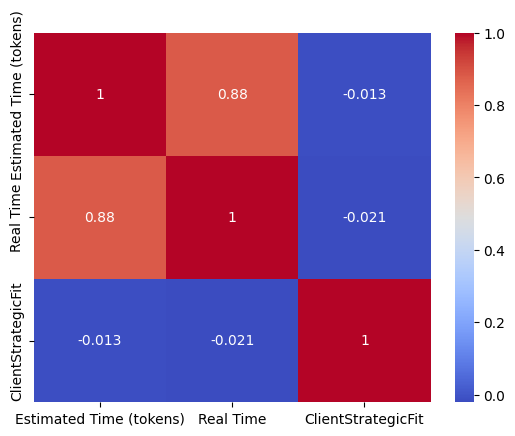

In [19]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

### LIMPIEZA Y FEATURE ENGINEERING 

In [21]:
df

,Company,Project Name,Input Date,Status,Requester,Request Type,Priority,Request,Device,Browser,Page,Estimated Time (tokens),Real Time,ClientStrategicFit
0,Lee PLC,Little Redesign – Chocolate,26/10/2020,Complete,Peter Pugh,Design Issues,Urgent,Reporting a detail in Little Redesign – Chocol...,Desktop,Safari,https://www.littleredesign–chocolate.com,3,2,2.09
1,"Murphy, Wright and Jensen",Sign Landing – DarkOliveGreen,15/11/2024,Complete,Monica Edwards,New Item,Normal,"Monica Edwards, Murphy, Wright and Jensen – sm...",Mobile,Safari,https://www.signlanding–darkolivegreen.com,8,5,3.33
2,Wilson and Sons,Decide Website – MediumOrchid,20/11/2021,Complete,Christopher Durham,New Item,Urgent,"Christopher Durham, Wilson and Sons – small is...",Mobile,Firefox,https://www.decidewebsite–mediumorchid.com,8,6,3.77
3,"Sosa, Bell and King",Military Campaign – MediumSeaGreen,01/02/2020,Complete,Kenneth Hancock,Design Issues,High,"Hi all, reviewing Military Campaign – MediumSe...",Desktop,Chrome,https://www.militarycampaign–mediumseagreen.com,1,1,3.01
4,Monroe-Hinton,Everybody Landing – OrangeRed,18/03/2022,Complete,Tammy Steele,New Item,Urgent,Reporting a detail in Everybody Landing – Oran...,Mobile,Safari,https://www.everybodylanding–orangered.com,5,4,1.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Wilson and Sons,Rate Redesign – DarkSlateBlue,15/12/2021,Complete,Catherine Long,Copy Revision,Low,Noticed something odd in the contact form. Con...,Desktop,Edge,https://www.rateredesign–darkslateblue.com,1,1,3.77
9996,Miles LLC,Outside Platform – Red,23/10/2021,Complete,Bryan Frazier,Copy Revision,Low,Hi there! Bryan Frazier from Miles LLC here. T...,Desktop,Safari,https://www.outsideplatform–red.com,2,2,3.39
9997,Davis-Hernandez,Who Redesign – NavajoWhite,22/03/2024,Complete,Thomas Hoover,Requested Change,Normal,Reporting a detail in Who Redesign – NavajoWhi...,Desktop,Firefox,https://www.whoredesign–navajowhite.com,13,10,3.01
9998,Brown-Flores,Place Revamp – PaleGoldenRod,22/04/2024,Complete,Mark Woodard,New Item,Urgent,Hi! I’m looking at Place Revamp – PaleGoldenRo...,Desktop,Safari,https://www.placerevamp–palegoldenrod.com,8,6,3.77


In [23]:
# lIMPIEZA DE COLUMNAS INNECESARIAS 
df2 = df.drop(columns=['Page', 'Input Date', 'Status', 'Browser', 'Device', 'Estimated Time (tokens)'])

In [25]:
df2 = df.drop(columns=['Company'])

In [32]:
# train test split

from sklearn.model_selection import train_test_split
X = df2['Request']
y = df2['Priority']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

              precision    recall  f1-score   support

        High       0.90      1.00      0.95       583
         Low       1.00      0.81      0.89       402
      Normal       0.98      1.00      0.99       633
      Urgent       1.00      1.00      1.00       382

    accuracy                           0.96      2000
   macro avg       0.97      0.95      0.96      2000
weighted avg       0.96      0.96      0.96      2000

0.961


<Axes: >

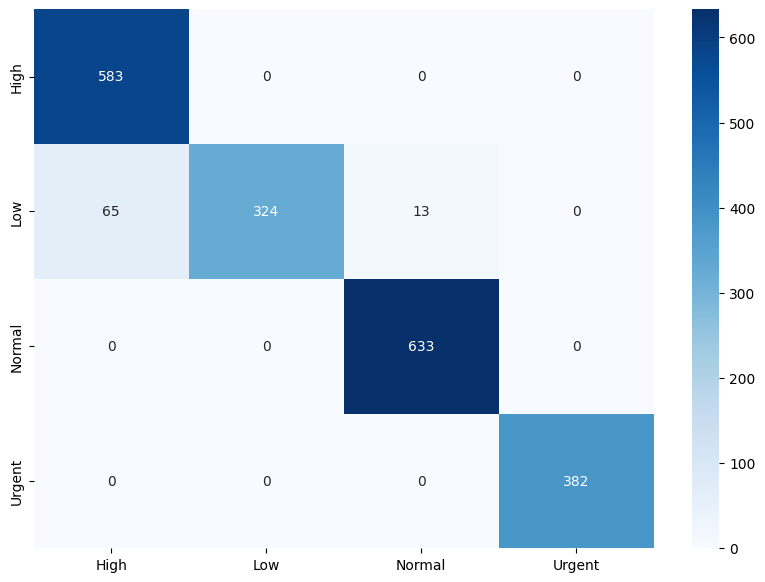

In [53]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
#natural language processing and pipeline with random forest classifier
from sklearn.pipeline import Pipeline   
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=3))
])
# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)
# Evaluate the model on the test data

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
# Confusion matrix
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)


#### EJEMPLOS DE REQUESTS

In [54]:
request_1 = "Please update the homepage banner to reflect the new campaign launch."


prediction = pipeline.predict([request_1])
print(f"Request: {request_1}")
print(f"Predicted Request Type: {prediction}")

Request: Please update the homepage banner to reflect the new campaign launch.
Predicted Request Type: ['Normal']


In [55]:
request_2 = "There is a typo in the About Us section that needs correction."

prediction = pipeline.predict([request_2])
print(f"Request: {request_2}")
print(f"Predicted Request Type: {prediction}")

Request: There is a typo in the About Us section that needs correction.
Predicted Request Type: ['Low']


In [56]:
request_3 = "The payment processing system is down and customers can't complete purchases."

prediction = pipeline.predict([request_3]) 
print(f"Request: {request_3}")
print(f"Predicted Request Type: {prediction[0]}")

Request: The payment processing system is down and customers can't complete purchases.
Predicted Request Type: High


In [57]:
request_4 = "Can you update my profile picture when you have a moment?"

prediction = pipeline.predict([request_4]) 
print(f"Request: {request_4}")
print(f"Predicted Priority: {prediction[0]}")

Request: Can you update my profile picture when you have a moment?
Predicted Priority: Low


In [ ]:
#DEBERÍA SER PRIORIDAD URGENTE
request_5 = "The payment system is down and customers can't complete their orders. Please fix this ASAP."

prediction = pipeline.predict([request_5]) 
print(f"Request: {request_5}")
print(f"Predicted Priority: {prediction[0]}")

Request: The payment system is down and customers can't complete their orders. Please fix this ASAP.
Predicted Priority: Normal


In [60]:
#debería ser prioridad MEDIA
request_6 = "We need to update the legal disclaimer across all landing pages by the end of the week."

prediction = pipeline.predict([request_6]) 
print(f"Request: {request_6}")
print(f"Predicted Priority: {prediction[0]}")

Request: We need to update the legal disclaimer across all landing pages by the end of the week.
Predicted Priority: High


In [38]:
import pickle
# Save the model to a file  

model_filename = 'priority_classifier.pkl'
with open(model_filename, 'wb') as model_file:
    pickle.dump(pipeline, model_file)   
    

#### PRUEBA CON OTRO MODELO PARA CAPTAR URGENCIA

**Tener en cuenta** Son pruebas, pero no será el modelo final para prioridad

**XLM-Roberta** es un modelo transformer preentrenado, que no funciona con texto crudo, sino que requiere que el texto se convierta a un formato especial llamado tokens.

Además, este modelo no es un clasificador tradicional sklearn, es un modelo de Deep Learning que se entrena con PyTorch o TensorFlow, requiere GPU para acelerar y tiene un entrenamiento más pesado.

**XLM-Roberta** trabaja con tensores numéricos, no con strings, por tanto, se necesita tokenizar el texto.

In [75]:
#!pip install transformers datasets torch


In [76]:
!pip install tf-keras

In [77]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from transformers import XLMRobertaTokenizerFast, XLMRobertaForSequenceClassification

In [78]:
from tqdm import tqdm



In [ ]:
# Codifica etiquetas (numéricas)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Tokenizador y tokenizar
tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=128)

#  Crear tensores para input_ids, attention_mask y labels
train_dataset = TensorDataset(
    torch.tensor(train_encodings['input_ids']),
    torch.tensor(train_encodings['attention_mask']),
    torch.tensor(y_train_enc)
)

test_dataset = TensorDataset(
    torch.tensor(test_encodings['input_ids']),
    torch.tensor(test_encodings['attention_mask']),
    torch.tensor(y_test_enc)
)

#  DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)  #En entrenamiento: Sí, para que 
# el modelo no vea siempre los datos en el mismo orden.

test_loader = DataLoader(test_dataset, batch_size=16)  # En evaluación/test: No, para que los resultados 
#sean reproducibles y el orden no afecte la evaluación.


#  Modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=len(le.classes_))
model.to(device)

#  Optimizer y loss
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss()

# Entrenar (una época de ejemplo)
model.train()
for batch in tqdm(train_loader):
    optimizer.zero_grad()
    input_ids = batch[0].to(device)
    attention_mask = batch[1].to(device)
    labels = batch[2].to(device)
    
    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()

# Evaluar
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=le.classes_))

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
  5%|▌         | 26/500 [03:15<51:05,  6.47s/it] 

In [ ]:
def predecir_prioridad(request_text):
    # 1. Tokenizar el texto
    inputs = tokenizer(request_text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    # 2. Inferencia
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        pred = torch.argmax(outputs.logits, dim=1).cpu().item()

    # 3. Decodificar la predicción
    prioridad = le.inverse_transform([pred])[0]
    return prioridad
# Ejemplo de uso

request_text = "The payment system is down and customers can't complete their orders. Please fix this ASAP."
print(f"Request: {request_text}")
print(f"Predicted Priority: {predecir_prioridad(request_text)}")

Request: The payment system is down and customers can't complete their orders. Please fix this ASAP.
Predicted Priority: Normal


In [ ]:
nuevo_request = "Please fix the system immediately. Customers are getting errors on checkout."
print(f"Request: {nuevo_request}")
print(f"Predicted Priority: {predecir_prioridad(nuevo_request)}")

Request: Please fix the system immediately. Customers are getting errors on checkout.
Predicted Priority: Normal


In [ ]:
request_3= "Multiple users are reporting data loss after saving forms. This needs immediate attention."

print(f"Request: {request_3}")
print(f"Predicted Priority: {predecir_prioridad(request_3)}")

Request: Multiple users are reporting data loss after saving forms. This needs immediate attention.
Predicted Priority: High


In [ ]:
request_4= "Can we update the font size in the FAQ section when you have time? It's a bit small."

print(f"Request: {request_4}")
print(f"Predicted Priority: {predecir_prioridad(request_4)}")

Request: Can we update the font size in the FAQ section when you have time? It's a bit small.
Predicted Priority: Low
